##### Dataset

In [ ]:
"""Generate half-circles and moons datasets with 1000 and 10000 samples"""

from sklearn.datasets import make_moons
import numpy as np

#make moon datasets
X_1k_moon, y_1k_moon = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_10k_moon, y_10k_moon = make_moons(n_samples=10000, noise=0.1, random_state=42)

#make half-circles datasets
X_1k_half = X_1k_moon.copy()
X_10k_half = X_10k_moon.copy()
#shift the second class down by 1.5 to create half-circles
X_1k_half[y_1k_moon == 1, 1] -= 1.5
X_10k_half[y_10k_moon == 1, 1] -= 1.5

y_1k_half = y_1k_moon.copy()
y_10k_half = y_10k_moon.copy()

#test the shapes of the datasets
print("Shapes of the Moon datasets:")
print(X_1k_moon.shape, y_1k_moon.shape)
print(X_10k_moon.shape, y_10k_moon.shape)
print("\n" + "-"*40 + "\n")
print("Shapes of the Half-Circle datasets:")
print(X_1k_half.shape, y_1k_half.shape)
print(X_10k_half.shape, y_10k_half.shape)

Shapes of the Moon datasets:
(1000, 2) (1000,)
(10000, 2) (10000,)

----------------------------------------

Shapes of the Half-Circle datasets:
(1000, 2) (1000,)
(10000, 2) (10000,)


##### Visualization

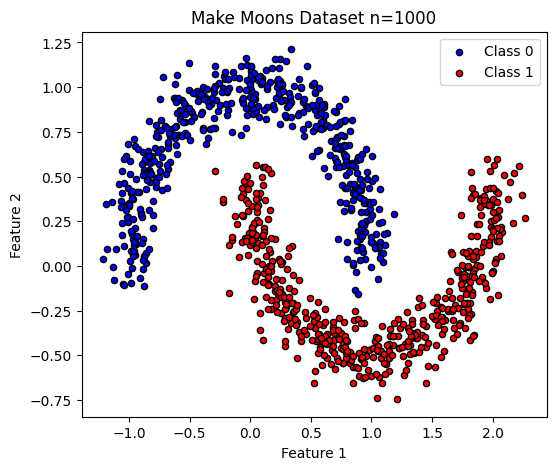

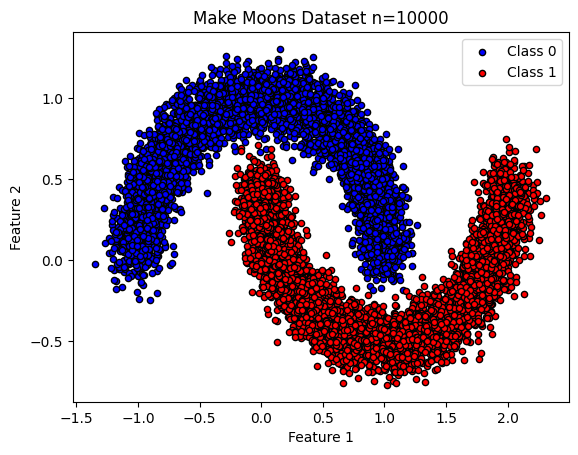

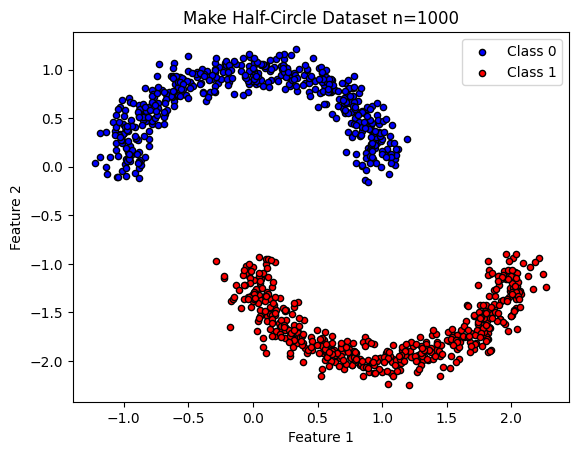

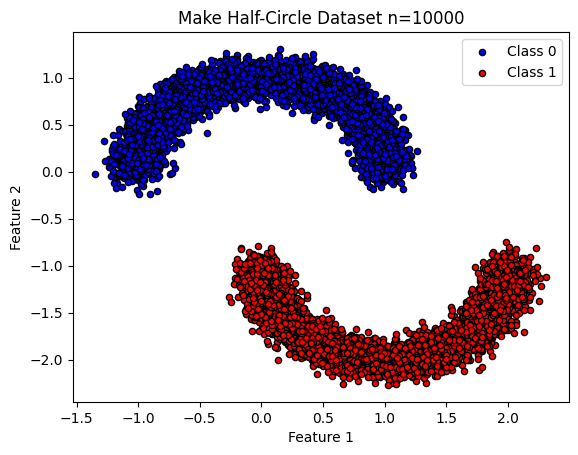

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

# 1K moon dataset
plt.scatter(
    X_1k_moon[y_1k_moon == 0, 0], X_1k_moon[y_1k_moon == 0, 1],
    color='blue',
    edgecolor='k',
    s=20,
    label='Class 0'
)
plt.scatter(
    X_1k_moon[y_1k_moon == 1, 0], X_1k_moon[y_1k_moon == 1, 1],
    color='red',
    edgecolor='k',
    s=20,
    label='Class 1'
)
plt.title("Make Moons Dataset n=1000")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# 10k moon dataset
plt.scatter(
    X_10k_moon[y_10k_moon == 0, 0], X_10k_moon[y_10k_moon == 0, 1],
    color='blue',
    edgecolor='k',
    s=20,
    label='Class 0'
)
plt.scatter(
    X_10k_moon[y_10k_moon == 1, 0], X_10k_moon[y_10k_moon == 1, 1],
    color='red',
    edgecolor='k',
    s=20,
    label='Class 1'
)
plt.title("Make Moons Dataset n=10000")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


# 1K half-circle dataset
plt.scatter(
    X_1k_half[y_1k_half == 0, 0], X_1k_half[y_1k_half == 0, 1],
    color='blue',
    edgecolor='k',
    s=20,
    label='Class 0'
)
plt.scatter(
    X_1k_half[y_1k_half == 1, 0], X_1k_half[y_1k_half == 1, 1],
    color='red',
    edgecolor='k',
    s=20,
    label='Class 1'
)
plt.title("Make Half-Circle Dataset n=1000")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# 10k half-circle dataset
plt.scatter(
    X_10k_half[y_10k_half == 0, 0], X_10k_half[y_10k_half == 0, 1],
    color='blue',
    edgecolor='k',
    s=20,
    label='Class 0'
)
plt.scatter(
    X_10k_half[y_10k_half == 1, 0], X_10k_half[y_10k_half == 1, 1],
    color='red',
    edgecolor='k',
    s=20,
    label='Class 1'
)
plt.title("Make Half-Circle Dataset n=10000")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()



##### Standardize Dataset

In [12]:
def standardize(X):
    mu = X.mean(axis=0)
    std = X.std(axis=0)
    return mu, std

def standardize_transform(X, mu, std):
    return (X - mu) / std

##### K-fold Cross Validation

In [43]:
"""Implement general k-fold cross validation (use 5 folds)"""
# This function generates train and test indices for k-fold cross-validation.
# random_state is used to ensure reproducibility when shuffling the indices.

def kfold_indices(n, k=5, shuffle=True, random_state=42):
    # generate random numbers with the given random state for reproducibility
    rng = np.random.default_rng(random_state)

    # split the indices into k folds
    idx = np.arange(n)
    if shuffle: rng.shuffle(idx)
    folds = np.array_split(idx, k)

    # 1 fold = test, remaining k-1 folds = train
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])
        yield train_idx, test_idx

##### Metrics

In [ ]:
def metrics(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1_score

##### Simple MLP
MLP (Multi-Layer Perceptron) is a type of feedforward neural network that learns non-linear relationships between inputs and outputs.
Input layer  →  Hidden layer(s)  →  Output layer